In [ ]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt

In [437]:
# Carregando os dados
df_teste=pd.read_csv('./Data/test.csv')
df_treino=pd.read_csv('./Data/train.csv')
y=pd.read_csv("./Data/gender_submission.csv")

<Axes: title={'center': 'Distribuição de Sobreviventes'}, xlabel='Survived'>

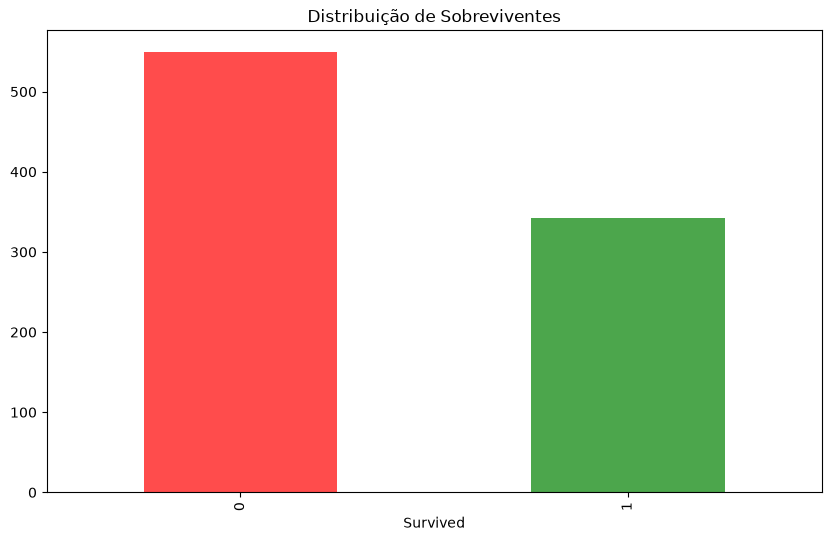

In [438]:
# plotando a distribuição de sobreviventes
plt.figure(figsize=(10, 6))
plt.title('Distribuição de Sobreviventes') 
df_treino['Survived'].value_counts().plot(kind='bar', color=['red', 'green'], alpha=0.7)

In [439]:
# Codificação da coluna 'Sex' usando LabelEncoder
labelencoder = LabelEncoder()
# Criando uma instância do LabelEncoder
df_treino['Sex'] = labelencoder.fit_transform(df_treino['Sex'])
df_teste['Sex'] = labelencoder.transform(df_teste['Sex'])

<Figure size 1000x600 with 0 Axes>

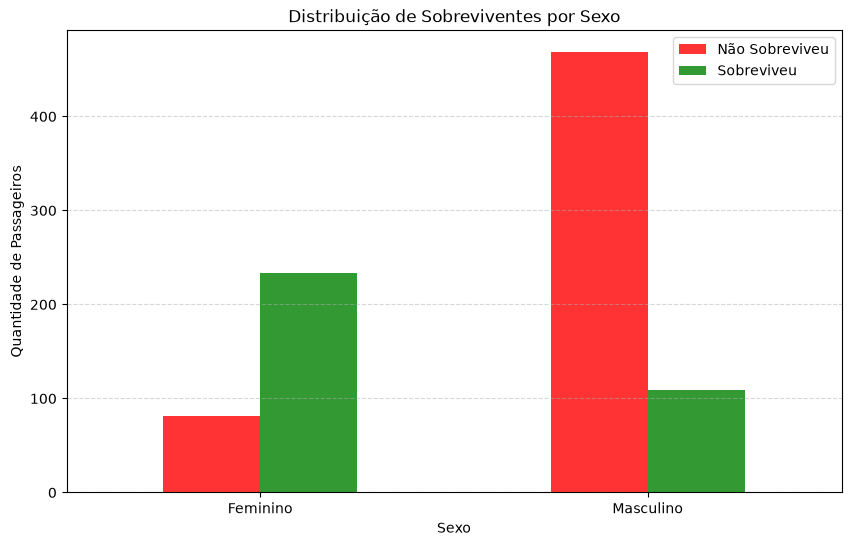

In [440]:
# Contagem de sobreviventes por sexo
dados = (
    df_treino
    .groupby(['Sex', 'Survived'])
    .size()
    .unstack(fill_value=0)
)

# Renomeando para ficar mais legível
dados.columns = ['Não Sobreviveu', 'Sobreviveu']
dados.index = ['Feminino', 'Masculino']

plt.figure(figsize=(10, 6))
dados.plot(
    kind='bar',
    figsize=(10, 6),
    color=['red', 'green'],
    alpha=0.8
)

plt.title('Distribuição de Sobreviventes por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade de Passageiros')
plt.xticks(rotation=0)
plt.legend(title='')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [441]:
NUM_ITERATIONS = 500
SCORING_METRIC = 'f1_micro'
NUM_JOBS = -1
CV_FOLDS = 5

In [ ]:
model = RandomizedSearchCV(RandomForestClassifier(), param_distributions={
    'n_estimators': range(10, 200, 10),
    'max_depth': range(10,200,10), 
    'min_samples_split': range(2,20,2)
    },cv=CV_FOLDS,n_jobs=NUM_JOBS, scoring=SCORING_METRIC, n_iter=NUM_ITERATIONS, verbose=1)

In [446]:

model = model.fit(df_treino[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']], df_treino['Survived'])


y_pred = model.predict(df_teste[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']])

y_true = y['Survived']

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


In [444]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       266
           1       0.84      0.78      0.81       152

    accuracy                           0.87       418
   macro avg       0.86      0.85      0.85       418
weighted avg       0.87      0.87      0.86       418



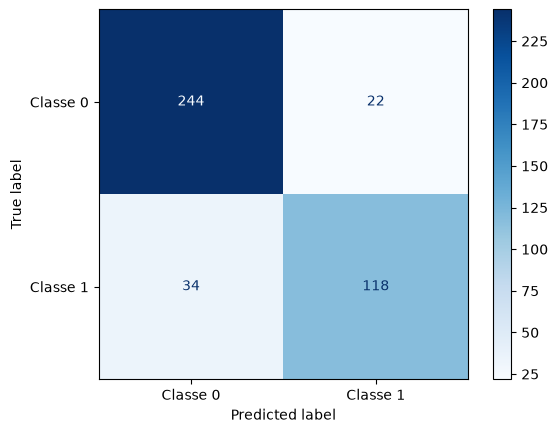

In [445]:
cm = confusion_matrix(y_true, y_pred)

# Plotagem
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap='Blues')